In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

In [5]:
train_data = pd.read_csv("Titanic-Dataset (1).csv")

train_data.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [7]:
train_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


In [8]:
train_data.describe()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


In [9]:
train_data.isnull().sum()

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

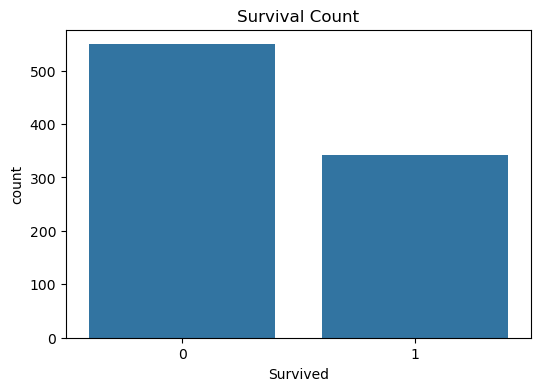

In [10]:
plt.figure(figsize=(6,4))
sns.countplot(x='Survived', data=train_data)

plt.title('Survival Count')
plt.show()

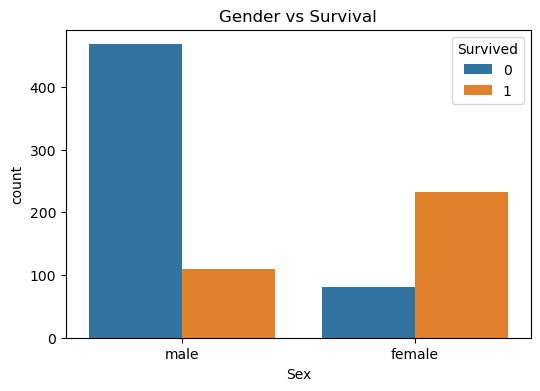

In [11]:
plt.figure(figsize=(6,4))
sns.countplot(x='Sex', hue='Survived', data=train_data)

plt.title('Gender vs Survival')
plt.show()

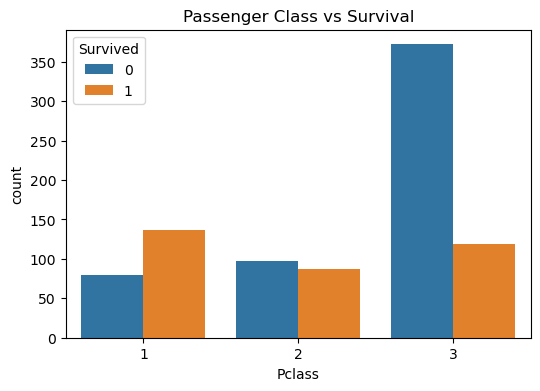

In [12]:
plt.figure(figsize=(6,4))
sns.countplot(x='Pclass', hue='Survived', data=train_data)

plt.title('Passenger Class vs Survival')
plt.show()

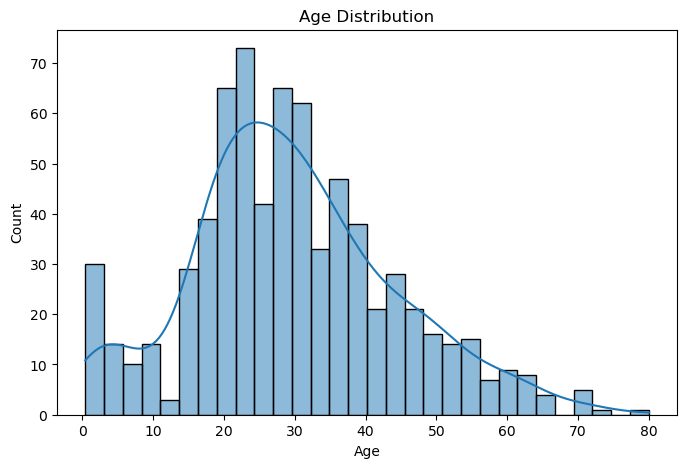

In [13]:
plt.figure(figsize=(8,5))
sns.histplot(train_data['Age'], bins=30, kde=True)

plt.title('Age Distribution')
plt.xlabel('Age')

plt.show()

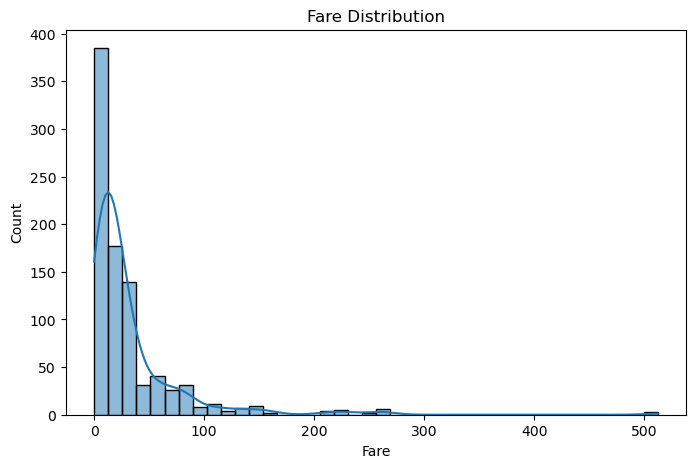

In [14]:
plt.figure(figsize=(8,5))
sns.histplot(train_data['Fare'], bins=40, kde=True)

plt.title('Fare Distribution')
plt.xlabel('Fare')

plt.show()

In [15]:
age_imputer = SimpleImputer(strategy='median')
train_data['Age'] = age_imputer.fit_transform(train_data[['Age']])

embarked_imputer = SimpleImputer(strategy='most_frequent')
train_data['Embarked'] = embarked_imputer.fit_transform(
    train_data[['Embarked']]
).ravel()

train_data.drop('Cabin', axis=1, inplace=True)

In [16]:
encoder = LabelEncoder()

train_data['Sex'] = encoder.fit_transform(train_data['Sex'])
train_data['Embarked'] = encoder.fit_transform(train_data['Embarked'])

In [17]:
X = train_data.drop(
    ['Survived', 'Name', 'Ticket', 'PassengerId'],
    axis=1
)
y = train_data['Survived']

In [18]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [19]:
logistic_model = LogisticRegression(max_iter=1000)

logistic_model.fit(X_train, y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,1000
,multi_class,'deprecated'


In [20]:
logistic_predictions = logistic_model.predict(X_test)

In [21]:
logistic_accuracy = accuracy_score(y_test, logistic_predictions)

print("Logistic Regression Accuracy:", logistic_accuracy)

Logistic Regression Accuracy: 0.8100558659217877


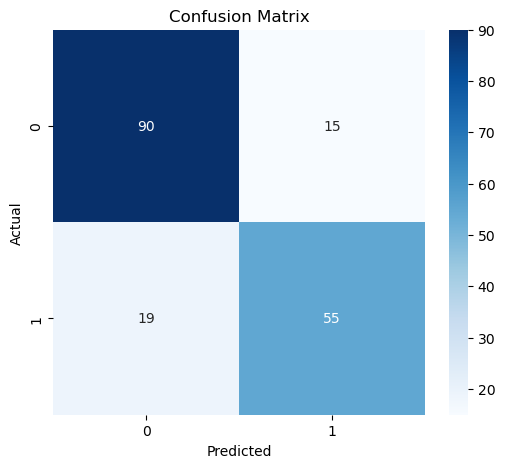

In [22]:
cm = confusion_matrix(y_test, logistic_predictions)

plt.figure(figsize=(6,5))

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')

plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')

plt.show()

In [23]:
print(classification_report(y_test, logistic_predictions))

              precision    recall  f1-score   support

           0       0.83      0.86      0.84       105
           1       0.79      0.74      0.76        74

    accuracy                           0.81       179
   macro avg       0.81      0.80      0.80       179
weighted avg       0.81      0.81      0.81       179



In [24]:
rf_model = RandomForestClassifier(
    n_estimators=200,
    random_state=42
)

rf_model.fit(X_train, y_train)

,n_estimators,200
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [25]:
rf_predictions = rf_model.predict(X_test)

In [26]:
rf_accuracy = accuracy_score(y_test, rf_predictions)

print("Random Forest Accuracy:", rf_accuracy)

Random Forest Accuracy: 0.8100558659217877


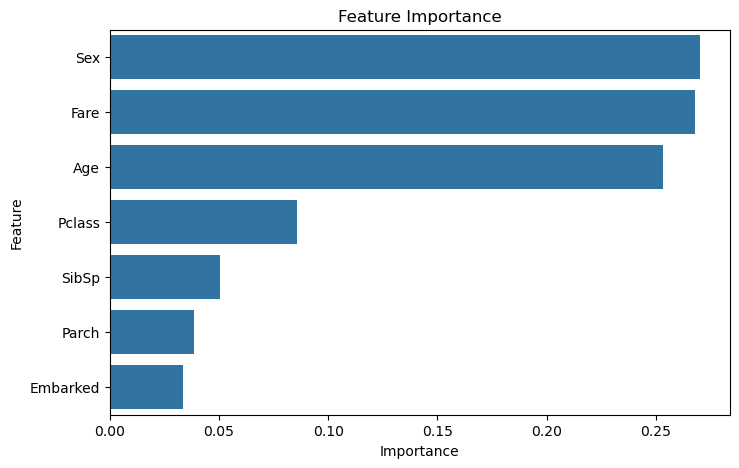

In [27]:
importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': rf_model.feature_importances_
})

importance = importance.sort_values(
    by='Importance',
    ascending=False
)

plt.figure(figsize=(8,5))

sns.barplot(
    x='Importance',
    y='Feature',
    data=importance
)

plt.title('Feature Importance')

plt.show()

In [28]:
models = ['Logistic Regression', 'Random Forest']

accuracies = [logistic_accuracy, rf_accuracy]

comparison = pd.DataFrame({
    'Model': models,
    'Accuracy': accuracies
})

comparison

,Model,Accuracy
0,Logistic Regression,0.810056
1,Random Forest,0.810056


In [29]:
sample_passenger = pd.DataFrame({
    'Pclass': [3],
    'Sex': [1],
    'Age': [22],
    'SibSp': [1],
    'Parch': [0],
    'Fare': [7.25],
    'Embarked': [2]
})

prediction = rf_model.predict(sample_passenger)

if prediction[0] == 1:
    print("The passenger would survive.")
else:
    print("The passenger would not survive.")

The passenger would not survive.
